## PrePrcess Data

In [16]:
import pandas as pd

# Load the CSV file
file_path = 'F:/_____My_Thesies____/Implimantation/3.Train_Model/1.Base_4_Models/4.Spec_VIs_GLCM_SAR/final_dataset_with_vis.csv'

df = pd.read_csv(file_path)

# Display basic info
print(f"Data shape: {df.shape}")  # (rows, columns)
print("\nFirst 5 columns:", df.columns.tolist()[:50])
print("\nLast 5 columns:", df.columns.tolist()[-50:])

Data shape: (6311, 3317)

First 5 columns: ['PXLVAL', 'B3_20240105', 'B4_20240105', 'B5_20240105', 'B6_20240105', 'B7_20240105', 'B8_20240105', 'B8A_20240105', 'B11_20240105', 'B12_20240105', 'B3_20240110', 'B4_20240110', 'B5_20240110', 'B6_20240110', 'B7_20240110', 'B8_20240110', 'B8A_20240110', 'B11_20240110', 'B12_20240110', 'B3_20240120', 'B4_20240120', 'B5_20240120', 'B6_20240120', 'B7_20240120', 'B8_20240120', 'B8A_20240120', 'B11_20240120', 'B12_20240120', 'B3_20240125', 'B4_20240125', 'B5_20240125', 'B6_20240125', 'B7_20240125', 'B8_20240125', 'B8A_20240125', 'B11_20240125', 'B12_20240125', 'B3_20240130', 'B4_20240130', 'B5_20240130', 'B6_20240130', 'B7_20240130', 'B8_20240130', 'B8A_20240130', 'B11_20240130', 'B12_20240130', 'B3_20240204', 'B4_20240204', 'B5_20240204', 'B6_20240204']

Last 5 columns: ['NDWI_20241220', '2BDA_20241220', 'NDCI_20241220', 'ENDVI_20241220', 'GNDVI_20241220', 'NDRE_20241220', 'GRVI_20241220', 'MSAVI_20241220', 'LSWI_20241220', 'NDMI_20241220', 'MNDW

In [17]:
# Function to report NA statistics
def report_nas(df, message):
    na_counts = df.isna().sum().sum()
    na_percent = (na_counts / (df.shape[0] * df.shape[1])) * 100
    print(f"{message}:")
    print(f"Total NAs: {na_counts:,} ({na_percent:.2f}% of all values)")
    print(f"Columns with NAs: {(df.isna().sum() > 0).sum()} out of {df.shape[1]}")
    print("-" * 50)

# Initial NA report
report_nas(df, "Initial NA status")

# Step 1: Drop columns with >50% NAs
threshold = df.shape[0] * 0.5
cols_to_drop = [col for col in df.columns if df[col].isna().sum() > threshold]
df = df.drop(columns=cols_to_drop)

report_nas(df, f"After dropping {len(cols_to_drop)} columns with >50% NAs")

# Step 2: Temporal interpolation for remaining NAs
def temporal_interpolation(df):
    # Get all date-based columns (spectral and VIs)
    date_cols = [col for col in df.columns if col.split('_')[-1].isdigit() and len(col.split('_')[-1]) == 8]
    date_cols_sorted = sorted(date_cols, key=lambda x: x.split('_')[-1])
    
    # Group by band/VI type
    from collections import defaultdict
    col_groups = defaultdict(list)
    for col in date_cols_sorted:
        prefix = '_'.join(col.split('_')[:-1])
        col_groups[prefix].append(col)
    
    # Perform interpolation for each group
    for prefix, cols in col_groups.items():
        # Forward and backward fill for edge cases
        df[cols] = df[cols].interpolate(method='linear', axis=1, limit_direction='both')
    
    return df

df = temporal_interpolation(df)
report_nas(df, "After temporal interpolation (same band across dates)")

# Step 3: Spatial interpolation (same date across bands)
def spatial_interpolation(df):
    date_cols = [col for col in df.columns if col.split('_')[-1].isdigit() and len(col.split('_')[-1]) == 8]
    dates = sorted(list(set(col.split('_')[-1] for col in date_cols)))
    
    for date in dates:
        # Get all columns for this date
        date_columns = [col for col in df.columns if col.endswith(date)]
        
        # Calculate mean of previous and next month for each NA
        for col in date_columns:
            # Skip if no NAs
            if df[col].isna().sum() == 0:
                continue
                
            # Extract date parts
            year = int(date[:4])
            month = int(date[4:6])
            day = int(date[6:8])
            
            # Find adjacent months
            prev_month = f"{year-1 if month == 1 else year}{month-1:02d}{day:02d}" if month > 1 else None
            next_month = f"{year+1 if month == 12 else year}{month+1:02d}{day:02d}" if month < 12 else None
            
            # Find available columns
            prefix = '_'.join(col.split('_')[:-1])
            candidates = []
            
            if prev_month:
                prev_col = f"{prefix}_{prev_month}"
                if prev_col in df.columns:
                    candidates.append(prev_col)
            
            if next_month:
                next_col = f"{prefix}_{next_month}"
                if next_col in df.columns:
                    candidates.append(next_col)
            
            # Fill NAs with mean of available adjacent months
            if candidates:
                df[col] = df[col].fillna(df[candidates].mean(axis=1))
    
    return df

df = spatial_interpolation(df)
report_nas(df, "After spatial interpolation (same date across bands)")

# Final NA check
remaining_nas = df.isna().sum().sum()
if remaining_nas > 0:
    print(f"Warning: {remaining_nas} NAs remaining after all processing steps")
    print("Columns with remaining NAs:")
    print(df.columns[df.isna().any()].tolist())
else:
    print("Success: All NAs have been handled!")

# # Optionally save the cleaned dataset
# clean_path = file_path.replace('.csv', '_clean.csv')
# df.to_csv(clean_path, index=False)
# print(f"\nCleaned dataset saved to: {clean_path}")

Initial NA status:
Total NAs: 2,264,528 (10.82% of all values)
Columns with NAs: 756 out of 3317
--------------------------------------------------
After dropping 364 columns with >50% NAs:
Total NAs: 332,080 (1.78% of all values)
Columns with NAs: 392 out of 2953
--------------------------------------------------
After temporal interpolation (same band across dates):
Total NAs: 0 (0.00% of all values)
Columns with NAs: 0 out of 2953
--------------------------------------------------
After spatial interpolation (same date across bands):
Total NAs: 0 (0.00% of all values)
Columns with NAs: 0 out of 2953
--------------------------------------------------
Success: All NAs have been handled!


## Find Labels

In [ ]:
import geopandas as gpd
import os

# === Updated Paths ===
raw_base = r"F:\_____My_Thesies____\_ImpFiles"

# Input Shapefiles
seg_shp = os.path.join(
    raw_base,
    "3. Feature Selection",
    "_Sentinel Data",
    "2. Divided Data",
    "6.Segmentation",
    "Seg_2024",
    "1. Opt",
    "2024_Seg_With_Mean_Opt.shp"
)

ref_shp = os.path.join(
    raw_base,
    "2.Segments",
    "_Final_Reference_Combined",
    "Ref_2024.shp"
)

# === Step 1: Load Shapefiles ===
try:
    segments_gdf = gpd.read_file(seg_shp)
    reference_gdf = gpd.read_file(ref_shp)
except Exception as e:
    print(f"❌ Failed to read shapefiles: {e}")
    raise SystemExit()

# === Step 2: CRS Check & Fix ===
if segments_gdf.crs != reference_gdf.crs:
    reference_gdf = reference_gdf.to_crs(segments_gdf.crs)
if segments_gdf.crs.is_geographic:
    segments_gdf = segments_gdf.to_crs(epsg=32639)
    reference_gdf = reference_gdf.to_crs(epsg=32639)

# === Step 3: Geometry Validation ===
segments_gdf = segments_gdf[segments_gdf.geometry.is_valid & ~segments_gdf.geometry.is_empty]
reference_gdf = reference_gdf[reference_gdf.geometry.is_valid & ~reference_gdf.geometry.is_empty]

print(f"\n✅ Segments Count: {len(segments_gdf)}, References Count: {len(reference_gdf)}")

# === Step 4: IoU & Labeling ===
label_column = "label"
segments_gdf[label_column] = None

iou_values = {}
weighted_iou_values = []
eliminated_polygons = []
over_segmentation_values = []

for ref_idx, ref_row in reference_gdf.iterrows():
    ref_geom = ref_row.geometry
    ref_label = ref_row["label"] if "label" in ref_row else ref_row.get("Name", f"Ref_{ref_idx}")
    ref_area = ref_geom.area

    # Find intersecting segments
    intersecting_segments = segments_gdf[segments_gdf.geometry.intersects(ref_geom)].copy()
    intersecting_segments["intersection_area"] = intersecting_segments.geometry.apply(
        lambda seg: seg.intersection(ref_geom).area if seg.is_valid else 0
    )
    intersecting_segments["segment_area"] = intersecting_segments.geometry.area
    intersecting_segments["overlap_ratio"] = intersecting_segments["intersection_area"] / intersecting_segments["segment_area"]

    significant_segments = intersecting_segments[intersecting_segments["overlap_ratio"] > 0.5]
    over_segmentation_values.append(len(significant_segments))

    if not significant_segments.empty:
        for idx in significant_segments.index:
            segments_gdf.at[idx, label_column] = ref_label
            segments_gdf.at[idx, "layer"] = ref_row["layer"]

        combined_geometry = significant_segments.geometry.union_all()
        intersection_area = combined_geometry.intersection(ref_geom).area
        union_area = combined_geometry.union(ref_geom).area
        iou = intersection_area / union_area if union_area > 0 else 0
        iou_values[ref_idx] = iou
        weighted_iou_values.append(iou * ref_area)
    else:
        if not intersecting_segments.empty:
            most_representative = intersecting_segments.loc[
                intersecting_segments["intersection_area"].idxmax()
            ]
            idx = most_representative.name
            segments_gdf.at[idx, label_column] = ref_label
            segments_gdf.at[idx, "layer"] = ref_row["layer"]

            intersection_area = most_representative.geometry.intersection(ref_geom).area
            union_area = most_representative.geometry.union(ref_geom).area
            iou = intersection_area / union_area if union_area > 0 else 0
            iou_values[ref_idx] = iou
            weighted_iou_values.append(iou * ref_area)
        else:
            iou_values[ref_idx] = 0
            eliminated_polygons.append(ref_idx)

print("\n✅ Labeling completed.")
print(f"ℹ️  Total labeled segments: {segments_gdf[label_column].notna().sum()}")
print(f"❌ References with no match: {len(eliminated_polygons)}")
print(f"📊 Mean IoU: {sum(iou_values.values()) / len(iou_values):.4f}")
print(f"📊 Weighted IoU: {sum(weighted_iou_values) / reference_gdf.geometry.area.sum():.4f}")

# === Step 5: Keep only necessary columns before saving ===
keep_columns = ['PXLVAL', label_column, 'layer', 'geometry']
segments_gdf = segments_gdf[[col for col in keep_columns if col in segments_gdf.columns]]

# Save cleaned shapefile
out_path = "F:/_____My_Thesies____/Implimantation/3.Train_Model/1.Base_4_Models/0. Data_Seprability/Seg_Labeled.shp"
segments_gdf.to_file(out_path)

print(f"\n✅ Labeled shapefile (with only PXLVAL and labels) saved to:\n{out_path}")



✅ Segments Count: 6311, References Count: 206

✅ Labeling completed.
ℹ️  Total labeled segments: 454
❌ References with no match: 0
📊 Mean IoU: 0.4825
📊 Weighted IoU: 0.6715

✅ Labeled shapefile (with only PXLVAL and labels) saved to:
F:/_____My_Thesies____/Implimantation/3.Train_Model/1.Base_4_Models/0. Data_Seprability/Seg_Labeled.shp


In [32]:
import geopandas as gpd

# Load the labeled shapefile
gdf = gpd.read_file(out_path)

# Select only needed columns
label_df = gdf[['PXLVAL', 'label', 'layer']].dropna(subset=['label'])

# Save to CSV
label_csv_path = shp_path.replace(".shp", "_LabelsOnly.csv")
label_df.to_csv(label_csv_path, index=False)
print(f"✅ Label CSV saved at:\n{label_csv_path}")


✅ Label CSV saved at:
F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\1. Opt\2024_Seg_With_Mean_Opt_Labeled_LabelsOnly.csv


In [35]:
import pandas as pd

# === Load your main features dataset ===
features_path = 'F:/_____My_Thesies____/Implimantation/3.Train_Model/1.Base_4_Models/4.Spec_VIs_GLCM_SAR/final_dataset_with_vis.csv'
df = pd.read_csv(features_path)

print(f"✅ Main dataset shape: {df.shape}")
print(f"🔍 First few PXLVALs:\n{df['PXLVAL'].head()}")

# === Load the label CSV exported from shapefile ===
label_csv_path = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\1.Base_4_Models\0. Data_Seprability\2024_Seg_With_Mean_Opt_Labeled_LabelsOnly.csv"
label_df = pd.read_csv(label_csv_path)

print(f"✅ Labels loaded. Shape: {label_df.shape}")
print(f"🔍 Sample:\n{label_df.head()}")

# === Merge on PXLVAL ===
df_labeled = df.merge(label_df, on='PXLVAL', how='left')

# === Summary of labeling ===
n_labeled = df_labeled['label'].notna().sum()
print(f"\n✅ Segments labeled: {n_labeled} out of {len(df_labeled)} ({n_labeled / len(df_labeled):.2%})")

# === Optional: save new labeled dataset ===
out_path = features_path.replace(".csv", "_with_labels.csv")
df_labeled.to_csv(out_path, index=False)
print(f"\n✅ Labeled dataset saved to:\n{out_path}")


✅ Main dataset shape: (6311, 3317)
🔍 First few PXLVALs:
0    119
1    152
2    166
3     31
4    153
Name: PXLVAL, dtype: int64
✅ Labels loaded. Shape: (454, 3)
🔍 Sample:
   PXLVAL    label          layer
0     105  Rice 50   Rice-polygon
1     108  Rice 49   Rice-polygon
2    1330   Gan 49  Wheat-polygon
3    1985   Gan 49  Wheat-polygon
4    2096   Gan 49  Wheat-polygon

✅ Segments labeled: 454 out of 6311 (7.19%)

✅ Labeled dataset saved to:
F:/_____My_Thesies____/Implimantation/3.Train_Model/1.Base_4_Models/4.Spec_VIs_GLCM_SAR/final_dataset_with_vis_with_labels.csv


In [5]:
# Reduce the dimension
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from numpy.linalg import inv, det
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# STEP 1: Reduce to Mean Features
# ===============================
# Define feature group prefixes
# === Load your main features dataset ===
features_path = 'F:/_____My_Thesies____/Implimantation/3.Train_Model/1.Base_4_Models/4.Spec_VIs_GLCM_SAR/final_dataset_with_vis_with_labels.csv'
df = pd.read_csv(features_path)

spectral_prefixes = ['B2_', 'B3_', 'B4_', 'B5_', 'B6_', 'B7_', 'B8_', 'B8A_', 'B11_', 'B12_']
vi_prefixes = ['NDVI_', 'EVI_', 'SAVI_', 'TDVI_', 'NDWI_', '2BDA_', 'NDCI_', 'ENDVI_', 'GNDVI_', 'NDRE_',
               'GRVI_', 'MSAVI_', 'LSWI_', 'NDMI_', 'MNDWI_', 'MBI_', 'EMBI_', 'MCARI2_']
sar_cols = ['VV', 'VH']
glcm_metrics = ['Contrast', 'Correlation', 'Dissimilarity', 'Entropy', 
                'Homogeneity', 'Second_Moment', 'Variance', 'Mean']

# Helper function to get mean values per group
def compute_group_means(df, prefixes):
    result = {}
    for prefix in prefixes:
        cols = [col for col in df.columns if col.startswith(prefix)]
        if len(cols) > 0:
            result[prefix.rstrip('_')] = df[cols].mean(axis=1)
    return pd.DataFrame(result)

def compute_glcm_metric_means(df, metrics):
    result = {}
    for metric in metrics:
        # Look for columns that contain _<metric>_
        cols = [col for col in df.columns if f"_{metric}_" in col]
        if len(cols) > 0:
            result[f"GLCM_{metric}"] = df[cols].mean(axis=1)
    return pd.DataFrame(result)

# Compute all feature group means
spec_means = compute_group_means(df, spectral_prefixes)
vi_means = compute_group_means(df, vi_prefixes)
glcm_means = compute_glcm_metric_means(df, glcm_metrics)
vv_cols = [col for col in df.columns if 'VV' in col]
vh_cols = [col for col in df.columns if 'VH' in col]

vv_mean = df[vv_cols].mean(axis=1).to_frame(name='VV_mean')
vh_mean = df[vh_cols].mean(axis=1).to_frame(name='VH_mean')

sar_features = pd.concat([vv_mean, vh_mean], axis=1)


# Final reduced feature set
features_reduced = pd.concat([spec_means, vi_means, sar_features, glcm_means], axis=1)
features_reduced = features_reduced.fillna(0)  # Replace NaNs
features_reduced_scaled = pd.DataFrame(StandardScaler().fit_transform(features_reduced),
                                       columns=features_reduced.columns)

# Attach labels
features_reduced_scaled['layer'] = df['layer'].values

print(f"✅ Final reduced feature matrix shape: {features_reduced_scaled.shape}")
print(f"✅ Sample per layer (for distance):\n{features_reduced_scaled['layer'].value_counts()}") 

C:\Users\mamad_js\AppData\Local\Temp\ipykernel_3184\1392107984.py:15: DtypeWarning: Columns (3317,3318) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(features_path)


✅ Final reduced feature matrix shape: (6311, 39)
✅ Sample per layer (for distance):
layer
Rice-polygon                    150
Wheat-polygon                   144
Bare-polygon                     39
Alfalfa-polygon                  33
Urban-polygon                    27
Phragmites-polygon               17
Clover-polygon                   14
Sugar_Beet-polygon                9
Corn-polygon                      6
Degreed_Wetland_Poly-polygon      6
Tamarix-polygon                   4
Mixed_TP-polygon                  3
Plowed-polygon                    2
Name: count, dtype: int64


In [24]:
# Check NaN ratio and basic stats
import pandas as pd

nan_ratios = features_reduced_scaled.isna().mean().sort_values(ascending=False)
print(nan_ratios[nan_ratios > 0])


layer    0.928062
dtype: float64


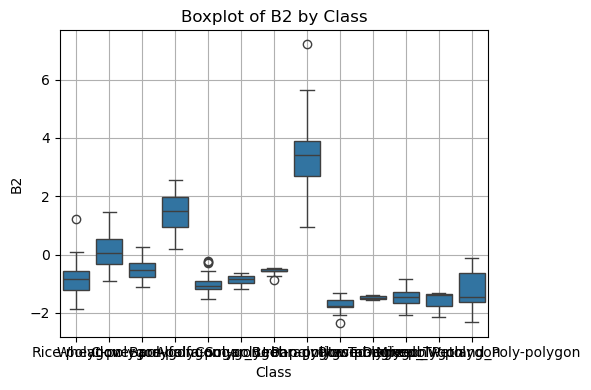

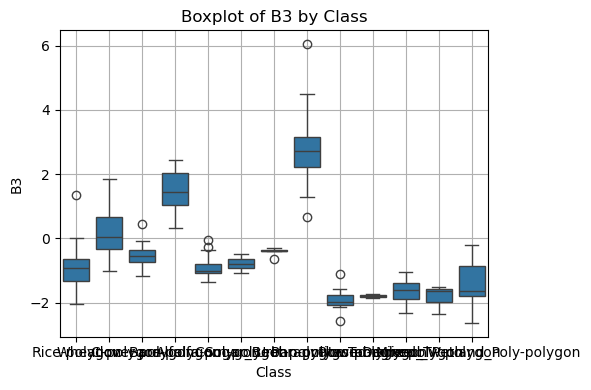

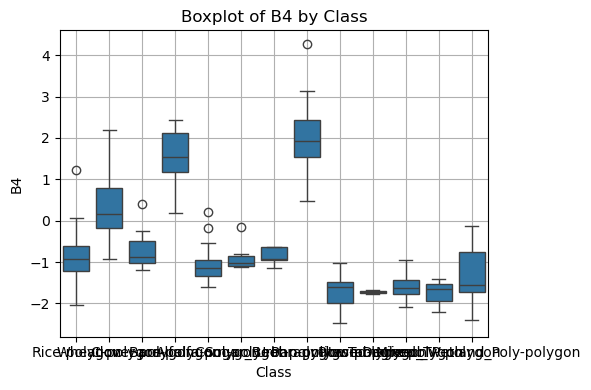

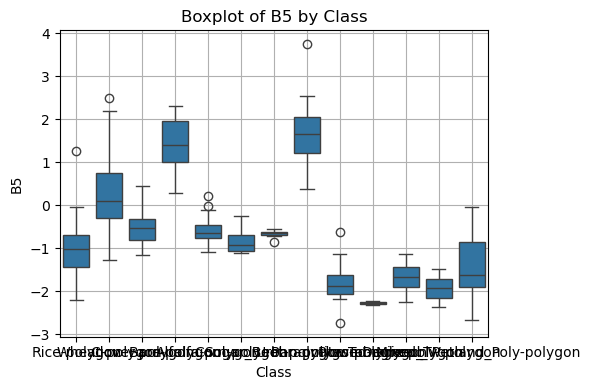

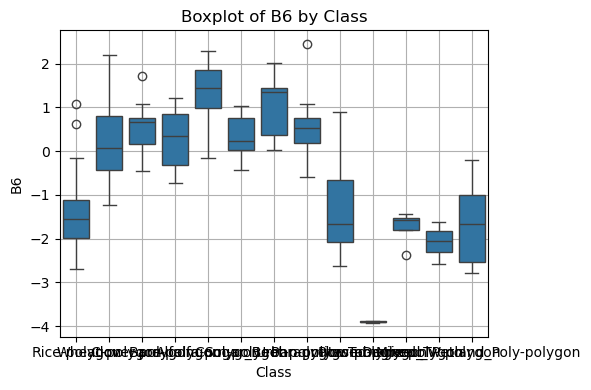

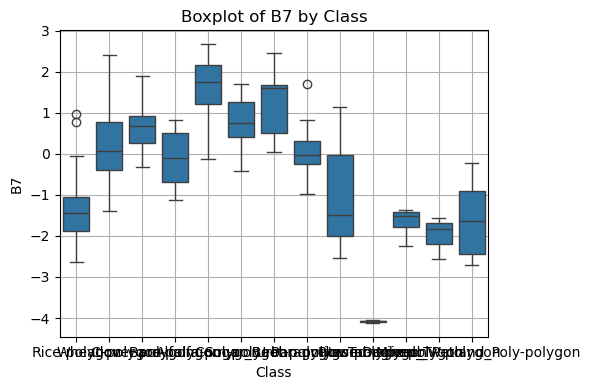

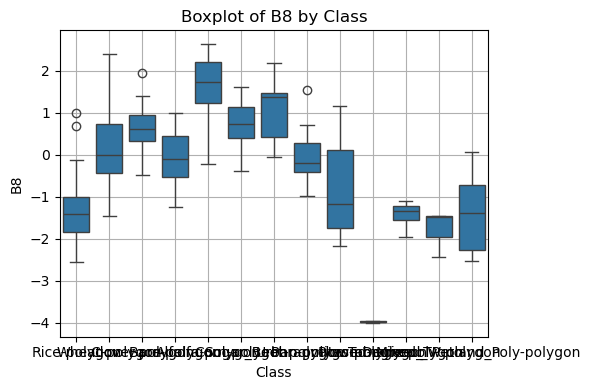

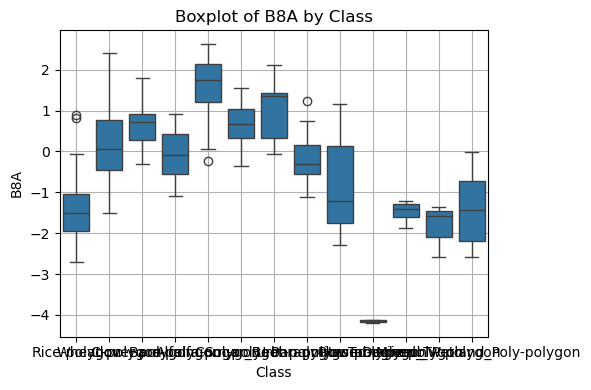

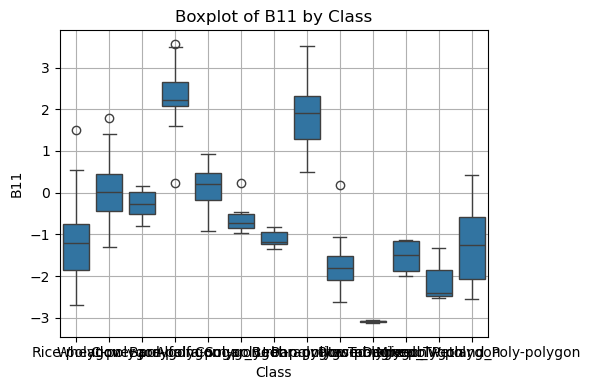

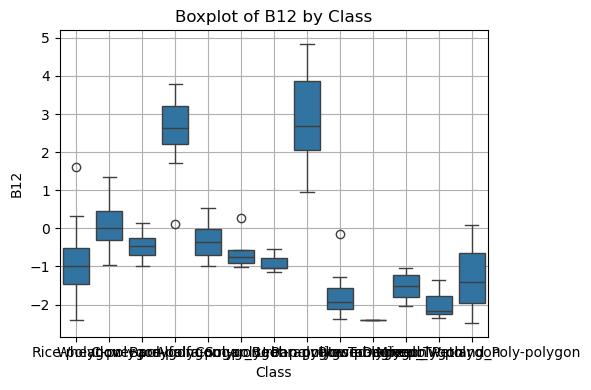

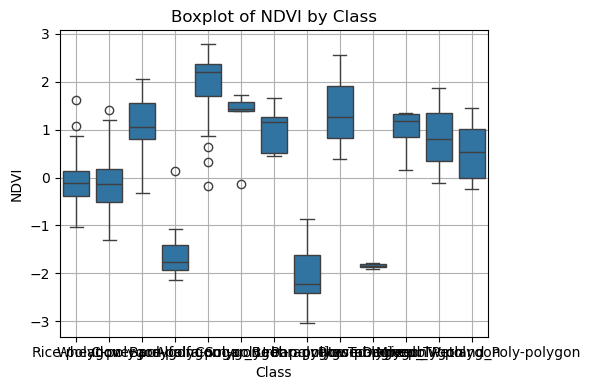

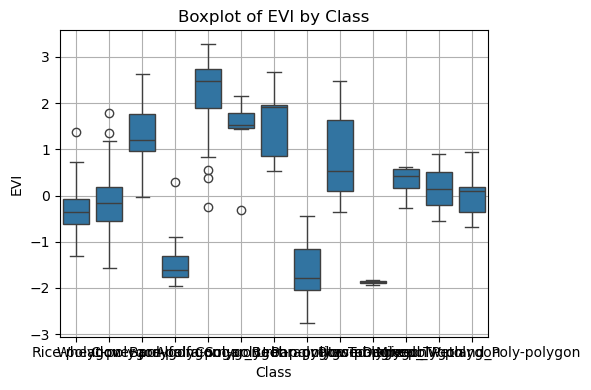

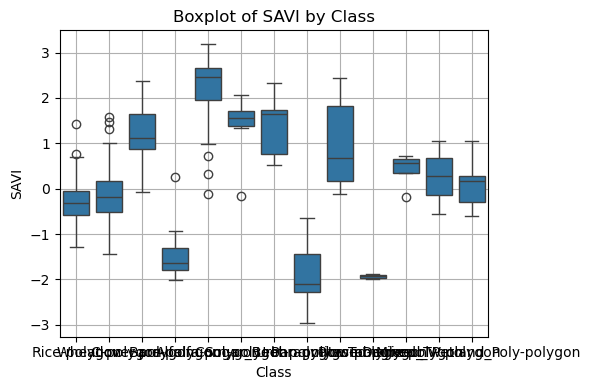

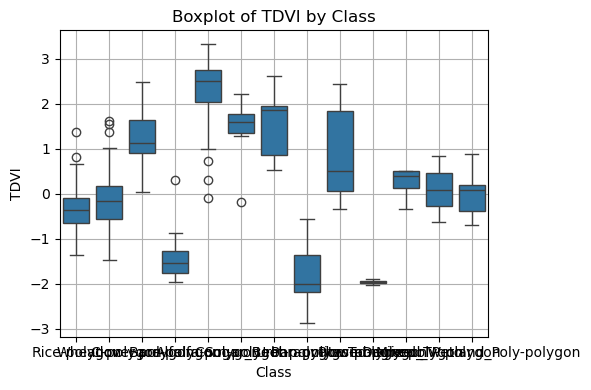

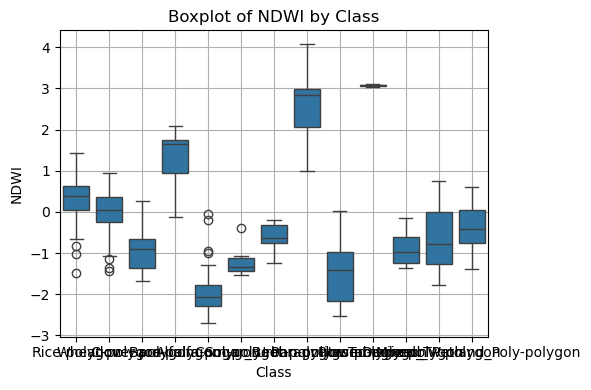

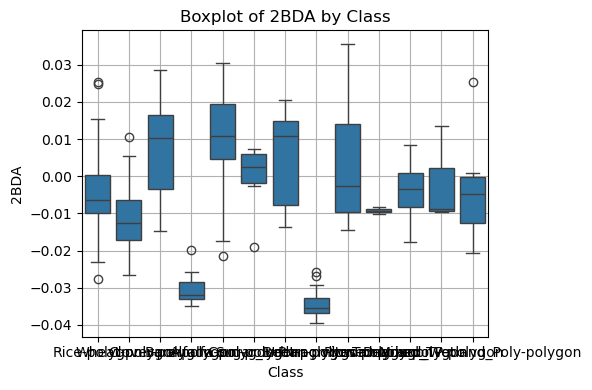

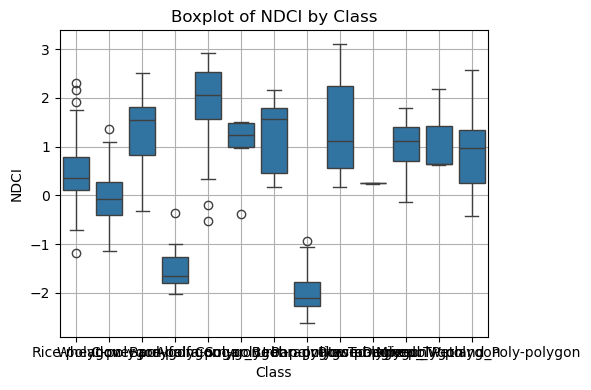

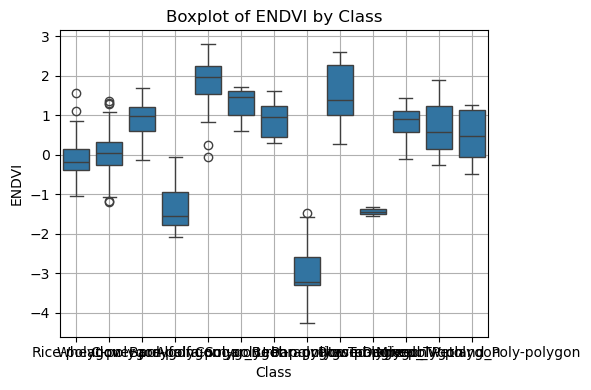

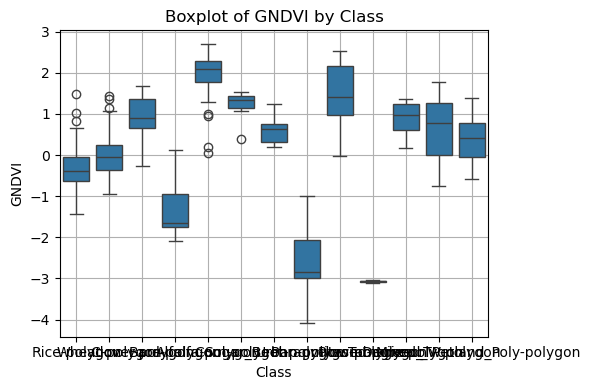

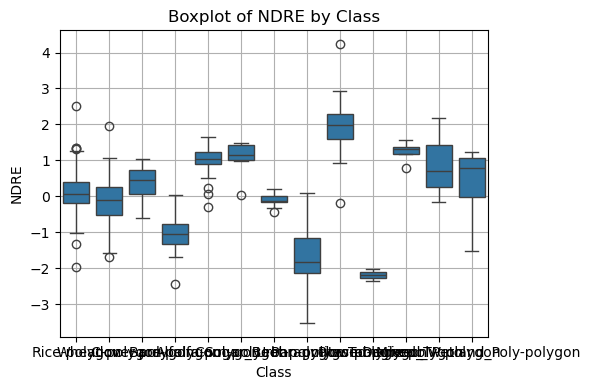

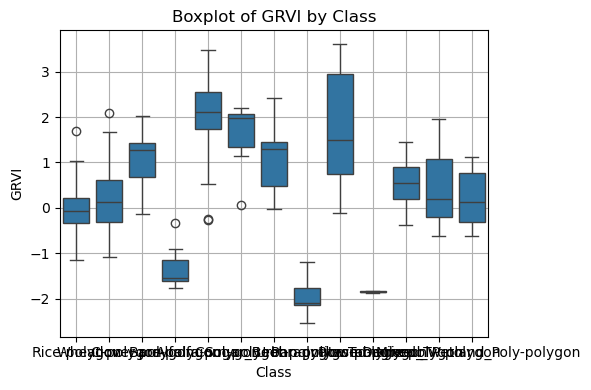

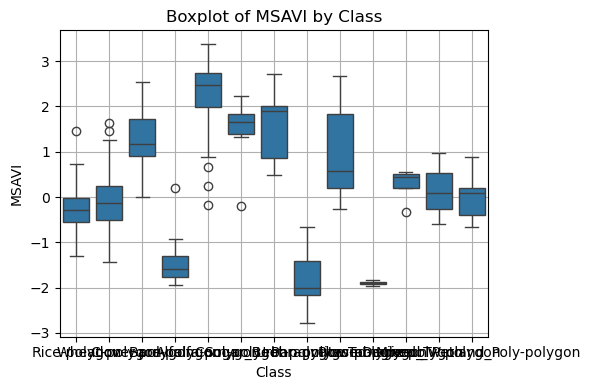

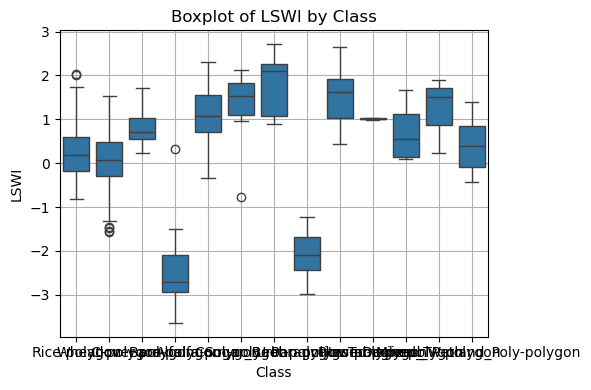

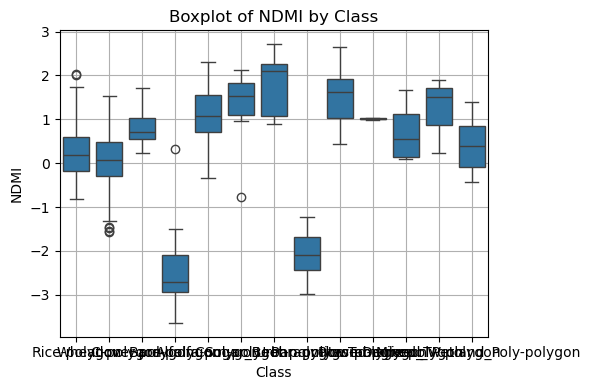

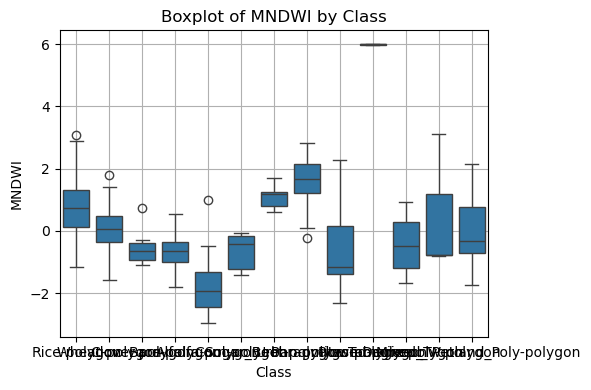

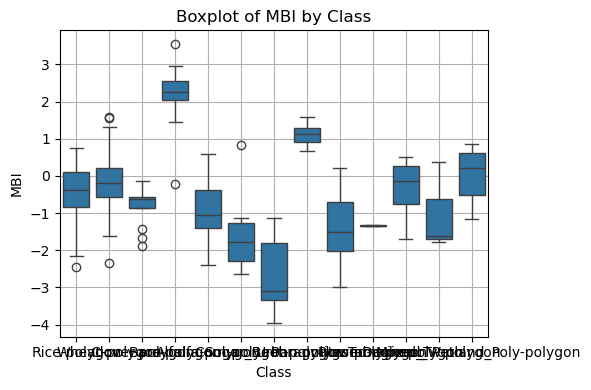

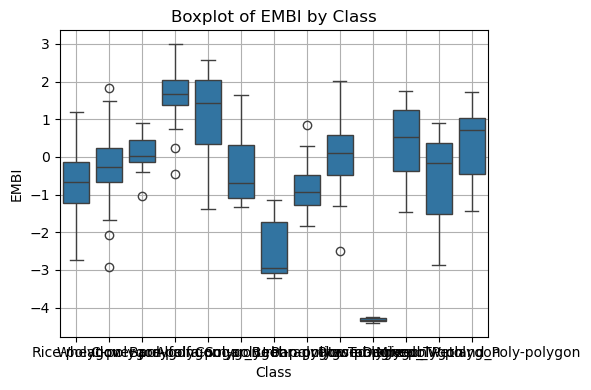

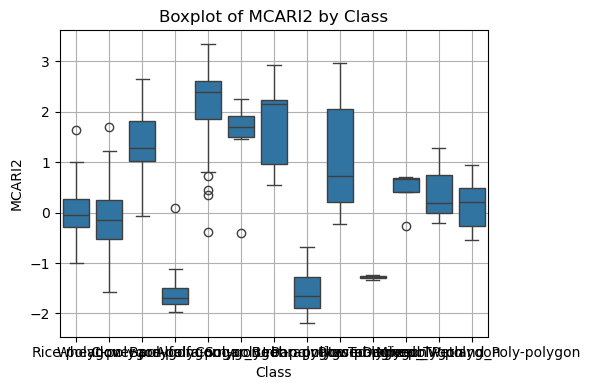

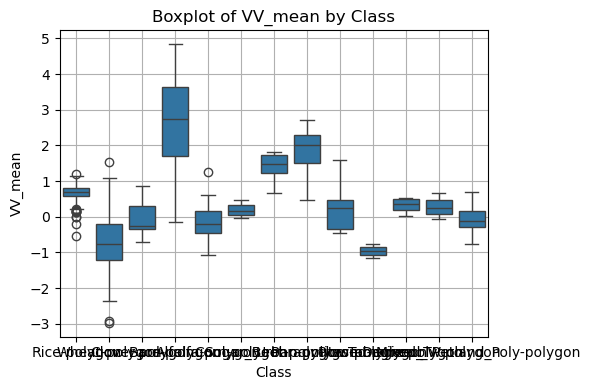

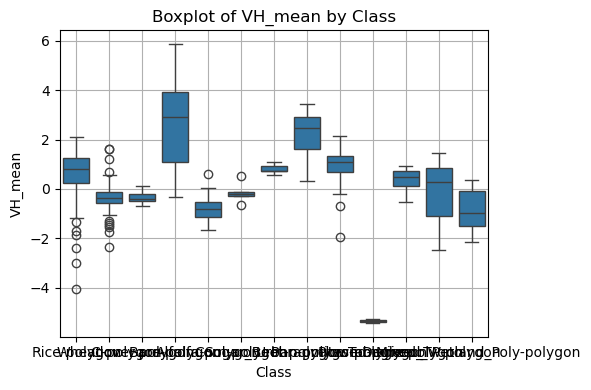

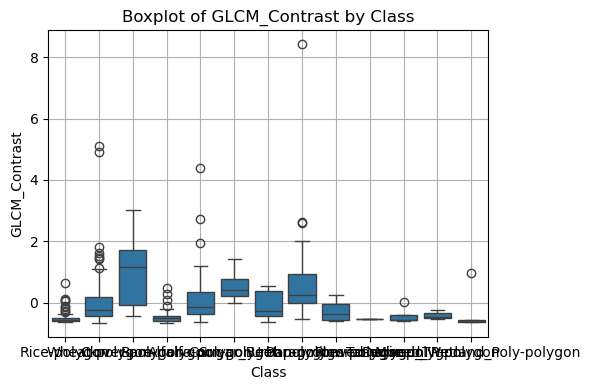

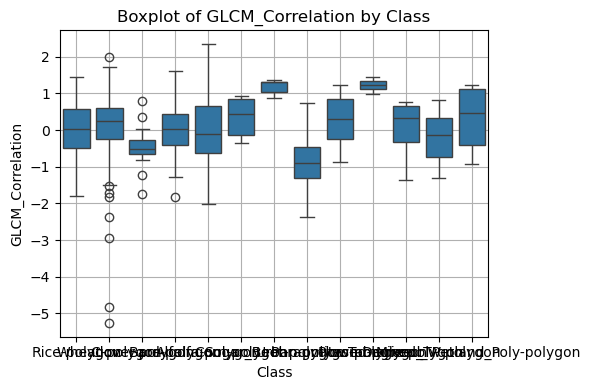

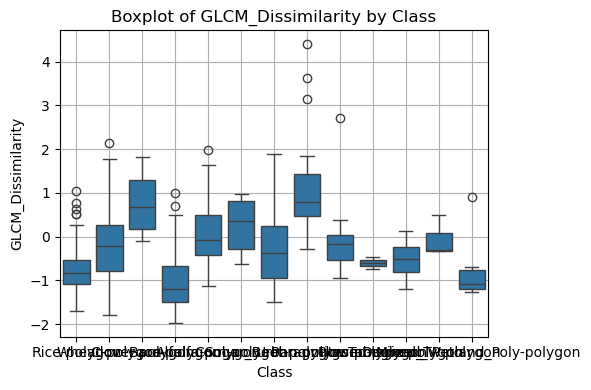

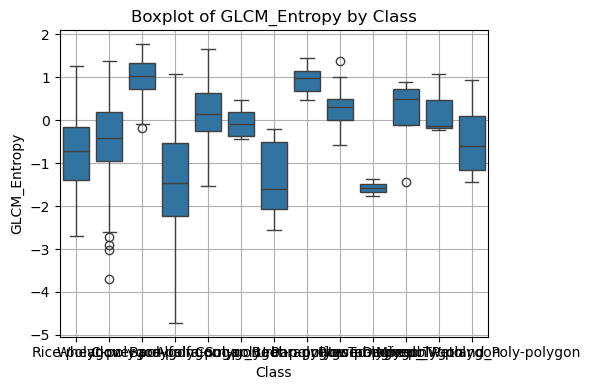

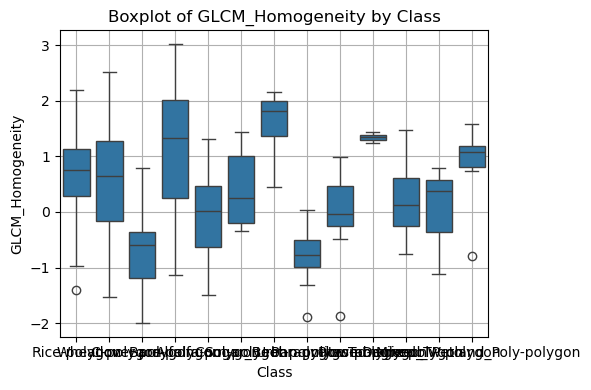

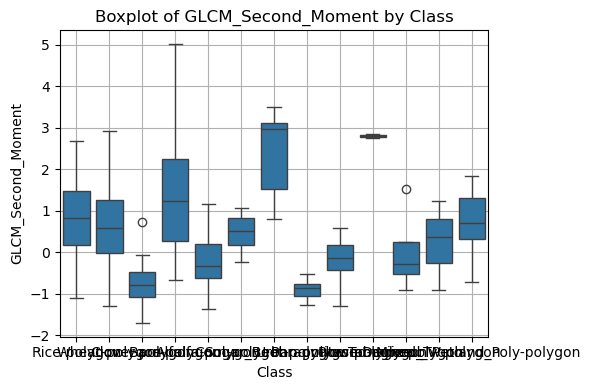

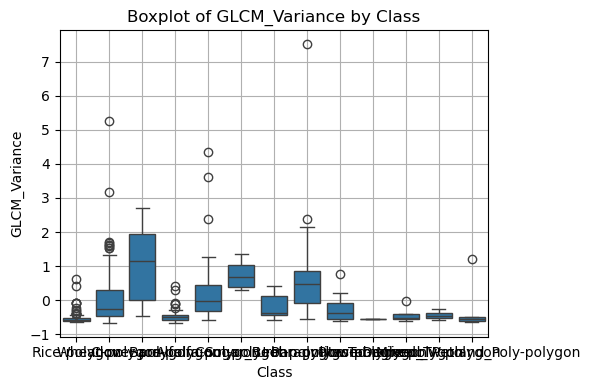

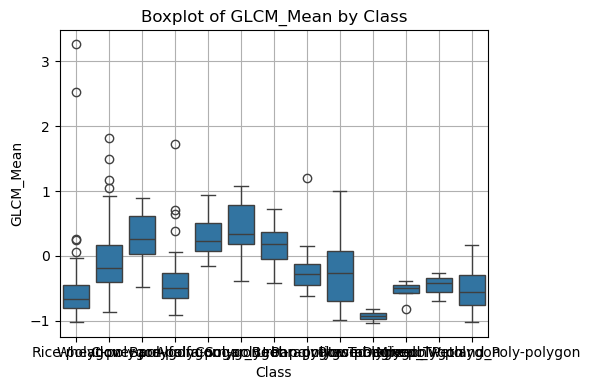

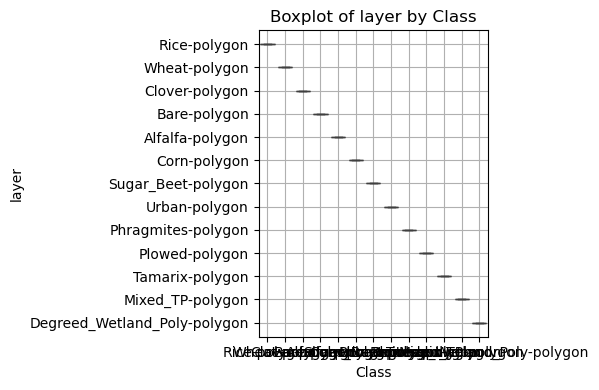

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# You already have y (the class labels), let's make a combined DataFrame
data_viz = features_reduced_scaled.copy()
data_viz['class'] = data_viz['layer']

# For each feature, plot boxplot
for col in features_reduced_scaled.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='class', y=col, data=data_viz)
    plt.title(f'Boxplot of {col} by Class')
    plt.xlabel('Class')
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu

def compute_separability_stats(df, label_col='layer'):
    features = df.drop(columns=[label_col]).columns
    layers = df[label_col].unique()
    
    t_stats = pd.DataFrame(index=layers, columns=features, dtype=float)
    u_stats = pd.DataFrame(index=layers, columns=features, dtype=float)

    for layer in layers:
        class_samples = df[df[label_col] == layer]
        rest_samples = df[df[label_col] != layer]
        
        for feature in features:
            x1 = class_samples[feature]
            x2 = rest_samples[feature]
            
            if len(x1) > 5 and len(x2) > 5:  # safe minimum size
                try:
                    t_stat, _ = ttest_ind(x1, x2, equal_var=False)
                    u_stat, _ = mannwhitneyu(x1, x2, alternative='two-sided')
                except Exception:
                    t_stat, u_stat = np.nan, np.nan
            else:
                t_stat, u_stat = np.nan, np.nan

            t_stats.loc[layer, feature] = abs(t_stat)  # use absolute value
            u_stats.loc[layer, feature] = u_stat  # raw U-stat

    return t_stats, u_stats
t_stats, u_stats = compute_separability_stats(features_reduced_scaled, label_col='layer')

In [30]:
top_t_features = t_stats.apply(lambda row: row.sort_values(ascending=False), axis=1)
top_u_features = u_stats.apply(lambda row: row.sort_values(ascending=False), axis=1)

print("Top 5 features per class (T-statistics):")
print(top_t_features)

print("\nTop 5 features per class (U-statistics):")
print(top_u_features)


Top 5 features per class (T-statistics):
                                  2BDA        B11        B12         B2  \
NaN                                NaN        NaN        NaN        NaN   
Rice-polygon                  0.378087  21.450315  18.706621  22.245465   
Wheat-polygon                 0.905667   1.640235   1.583943   2.068665   
Clover-polygon                0.554055   3.306233   5.378968   5.220360   
Bare-polygon                  2.443449  23.108982  22.842758  13.872992   
Alfalfa-polygon               0.801452   1.944744   4.343545  17.743510   
Corn-polygon                  0.036892   3.289233   3.232102  10.099741   
Sugar_Beet-polygon            0.369694  17.616893  12.707965  12.391353   
Urban-polygon                 2.736913  13.950426  15.290523  13.833970   
Phragmites-polygon            0.285283  10.508738  13.540854  26.546378   
Plowed-polygon                     NaN        NaN        NaN        NaN   
Tamarix-polygon                    NaN        NaN        Na

Visualizing top features for each class...


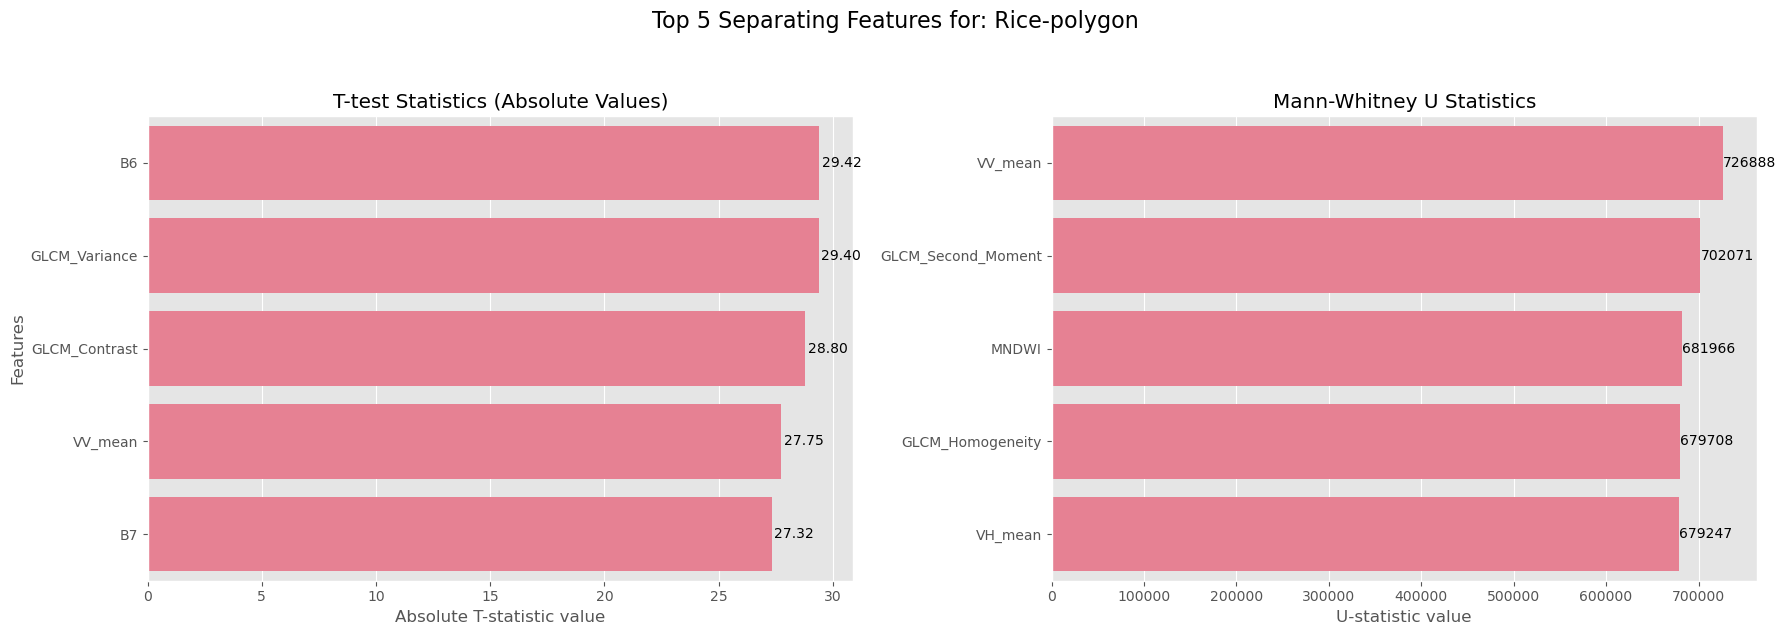

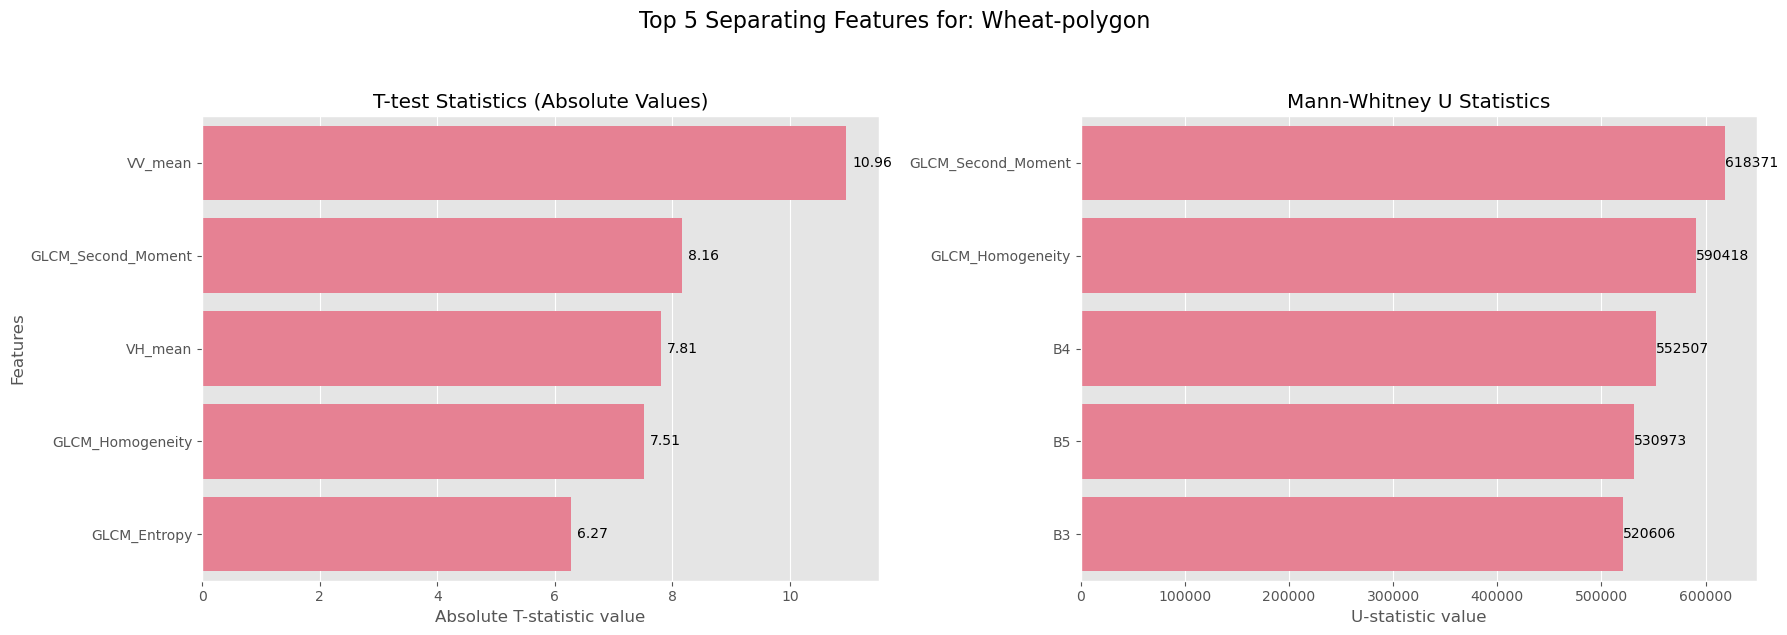

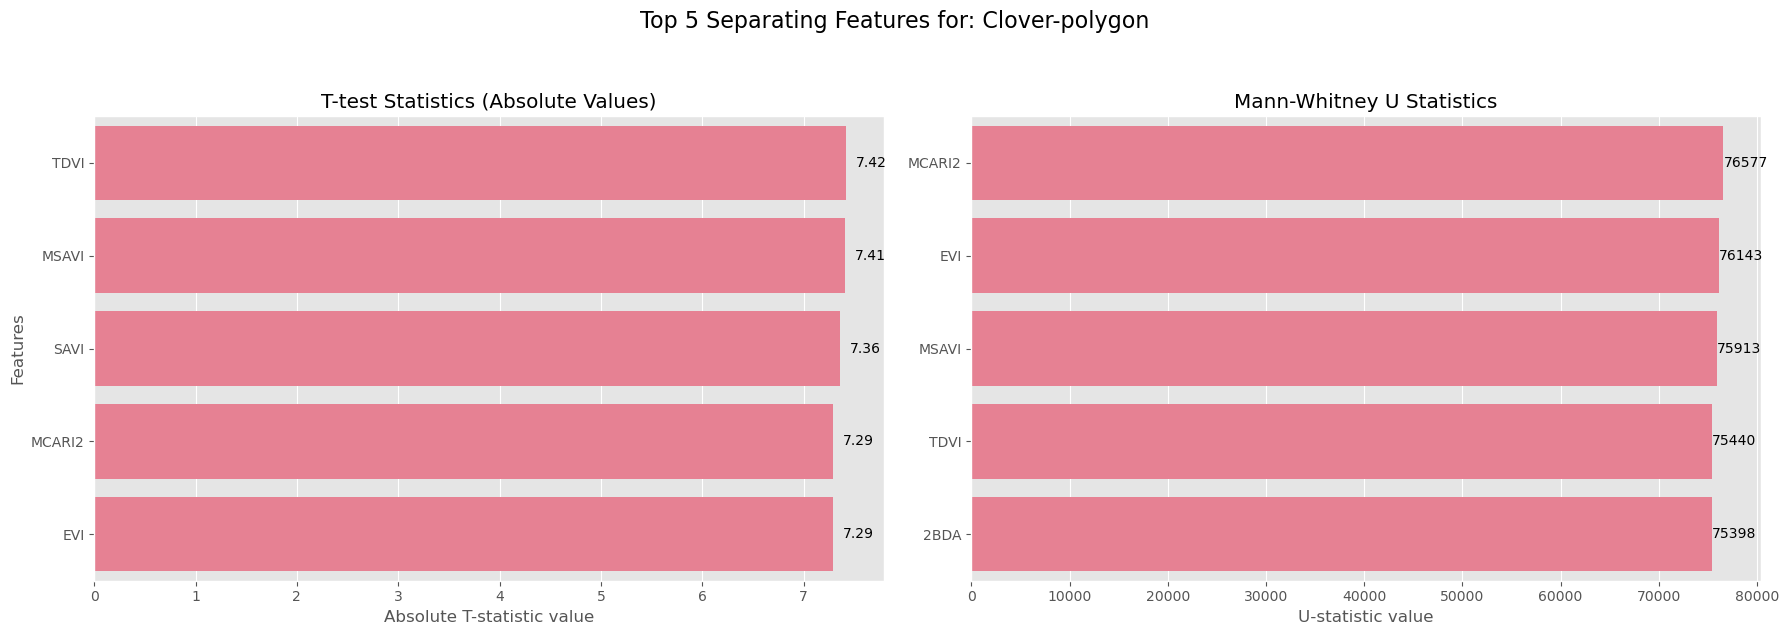

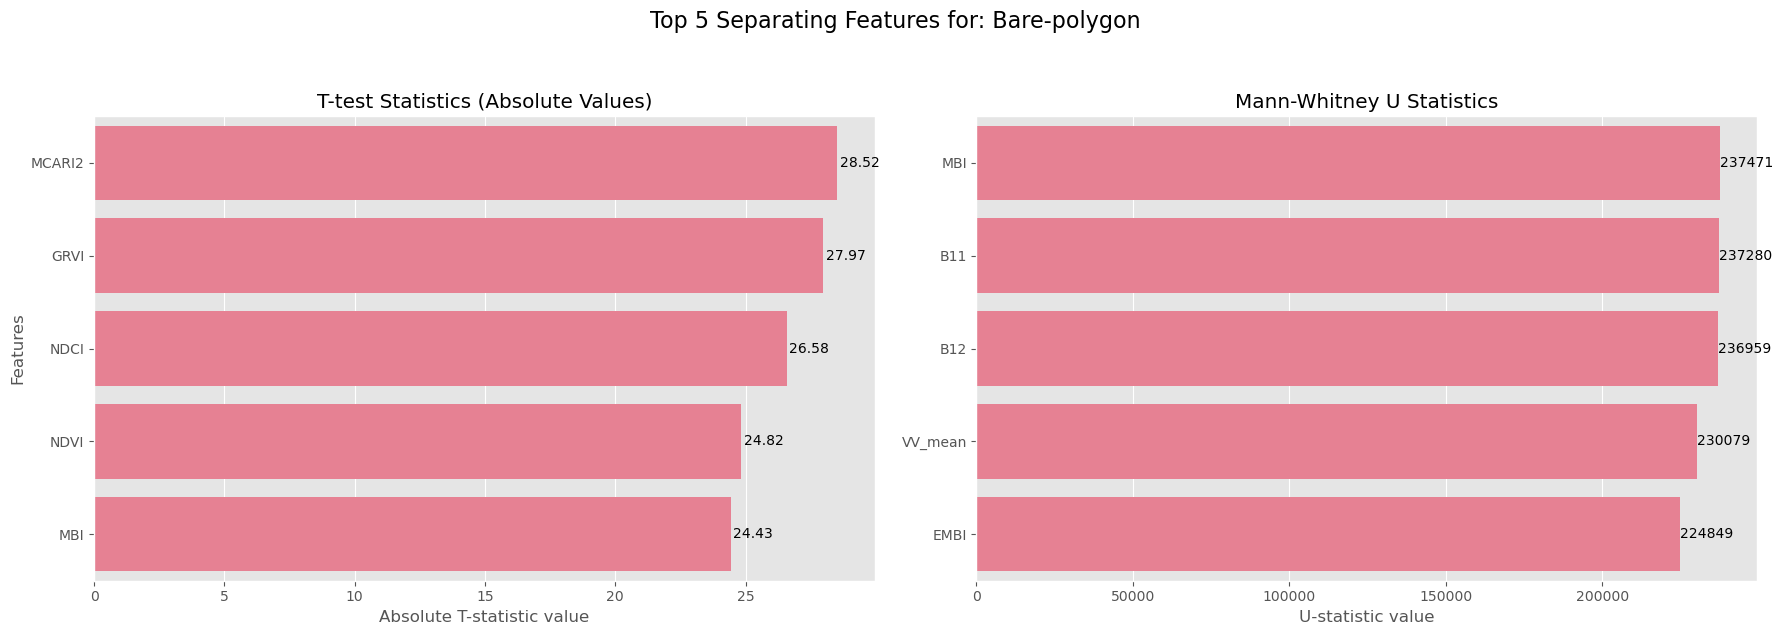

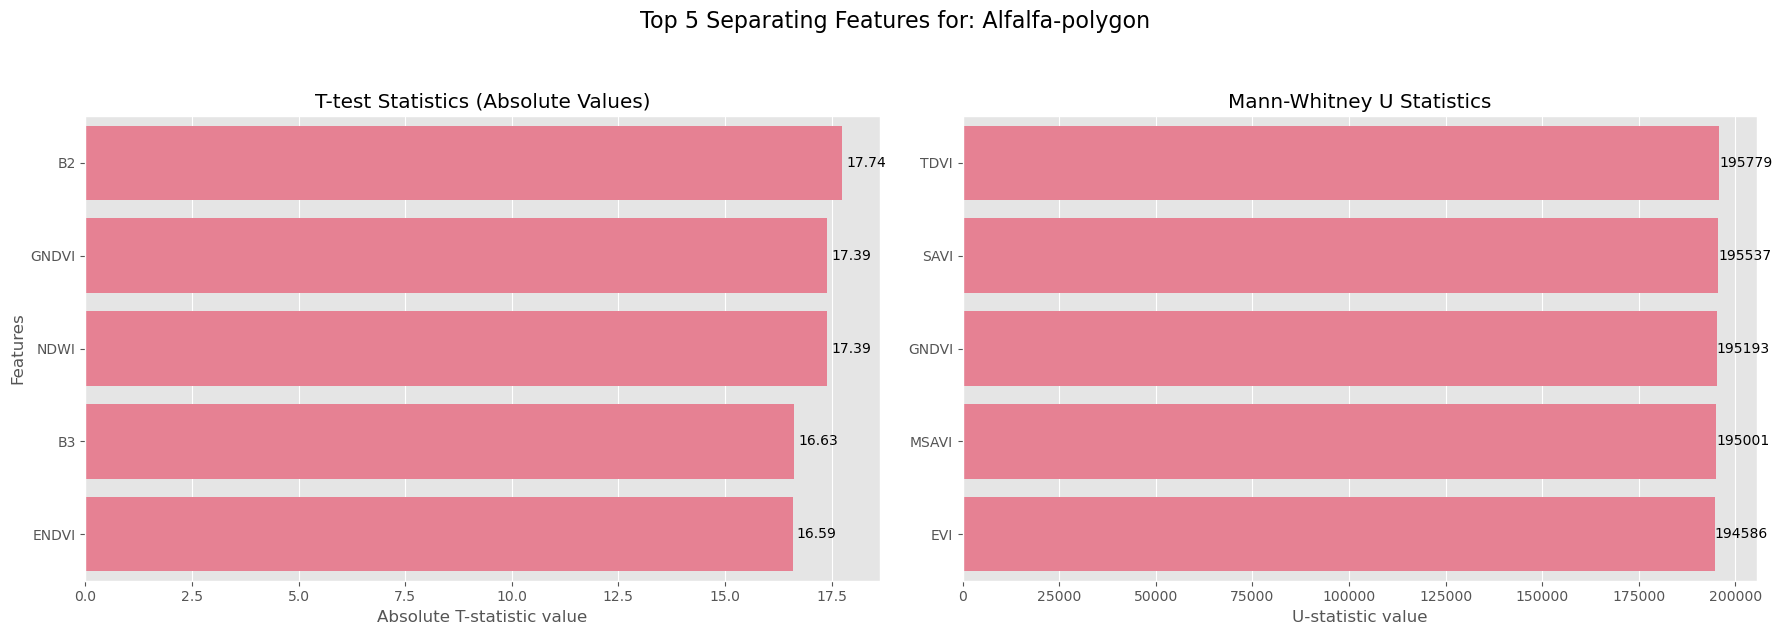

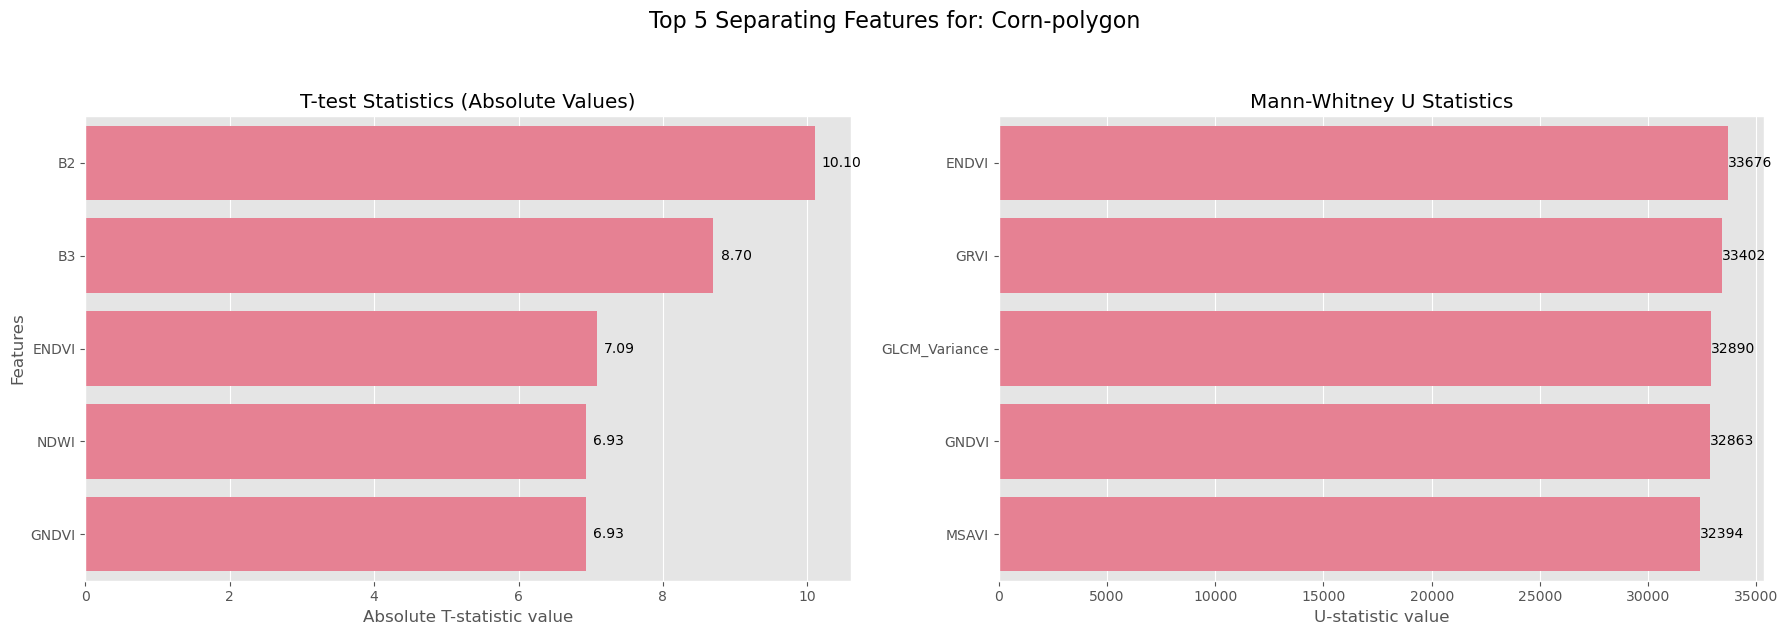

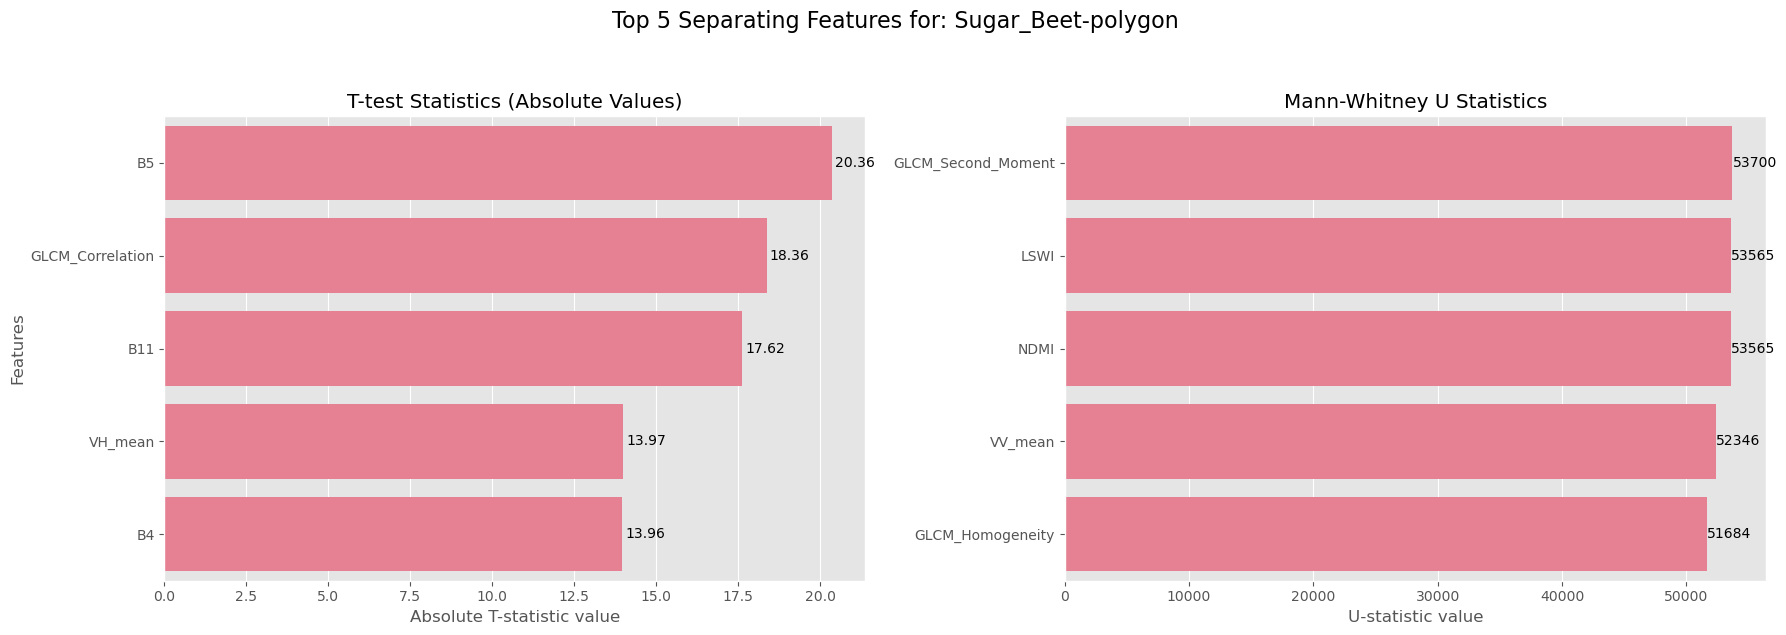

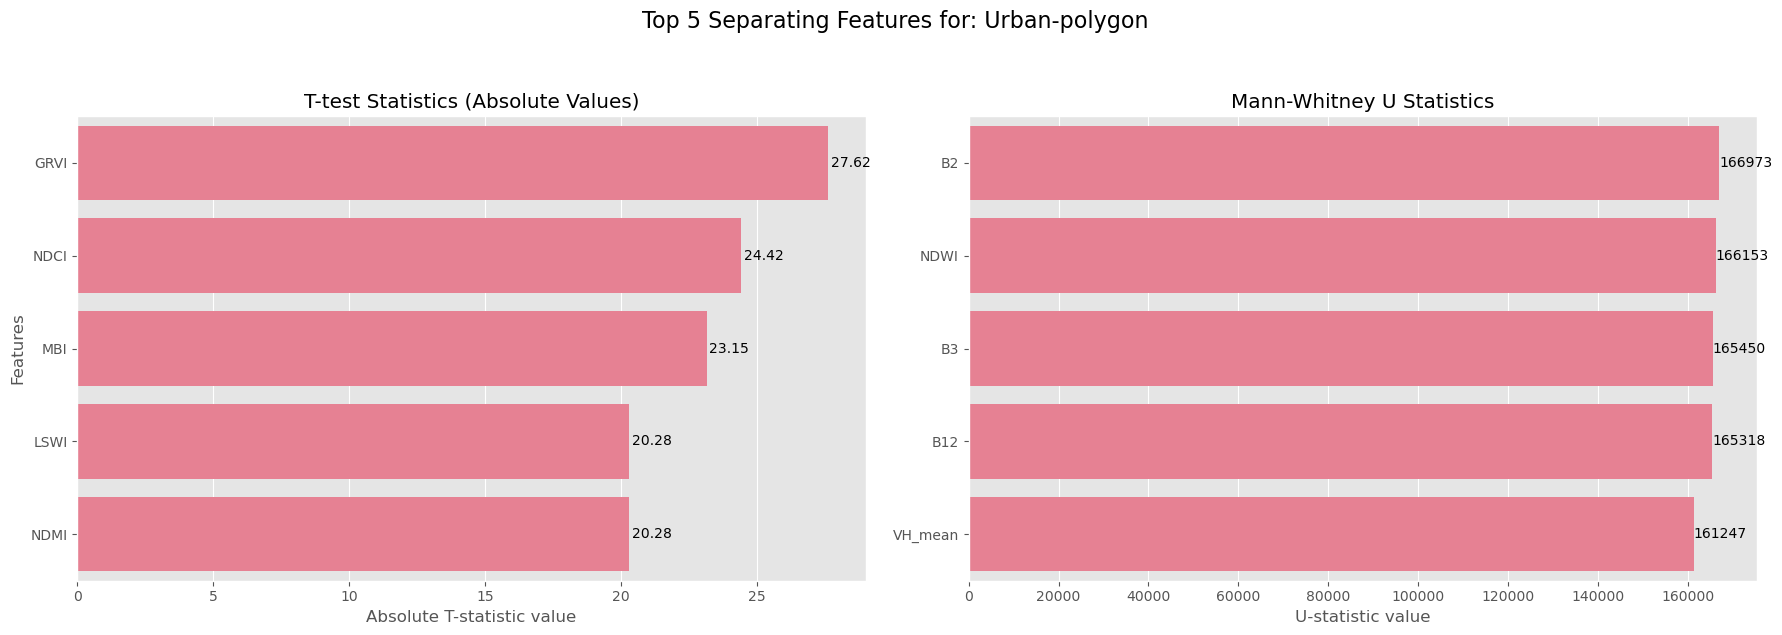

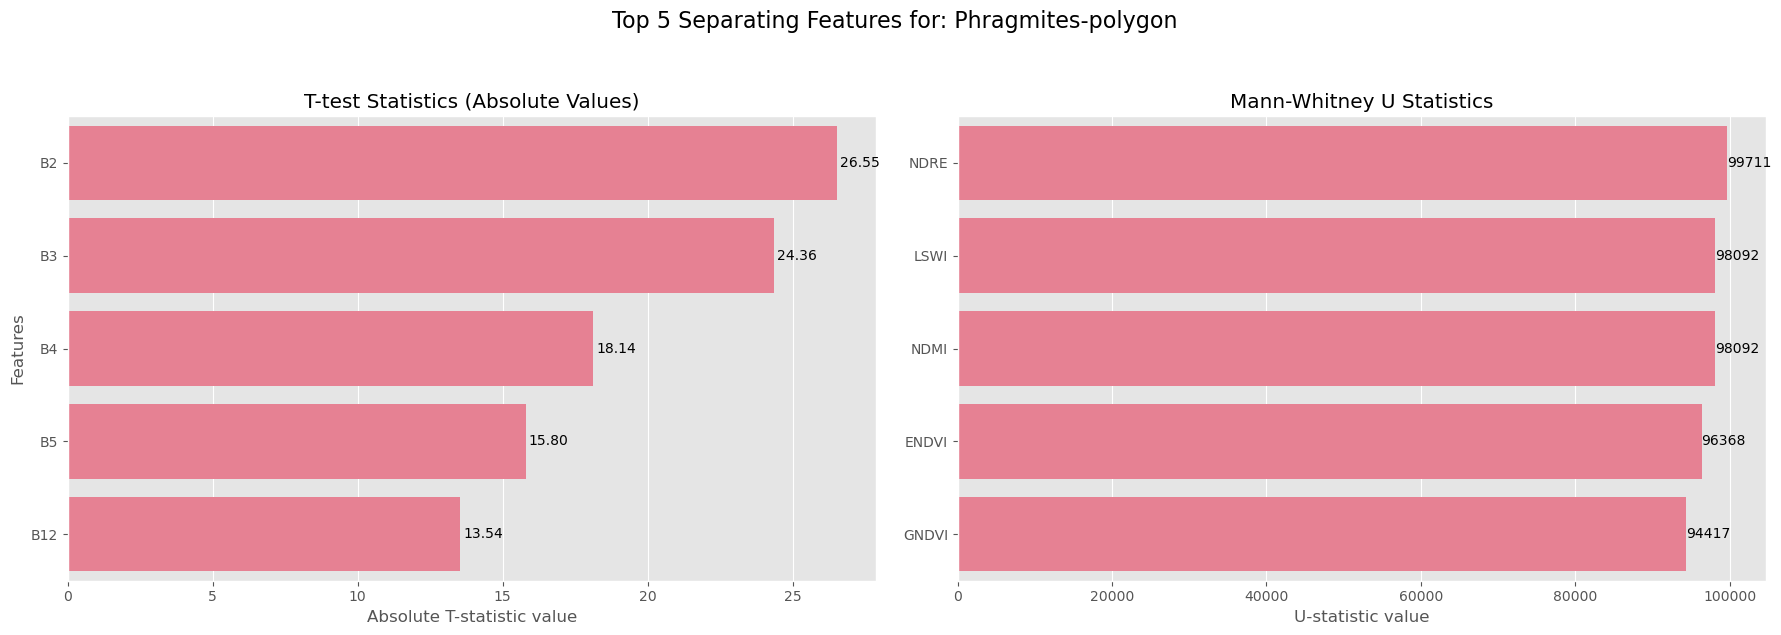

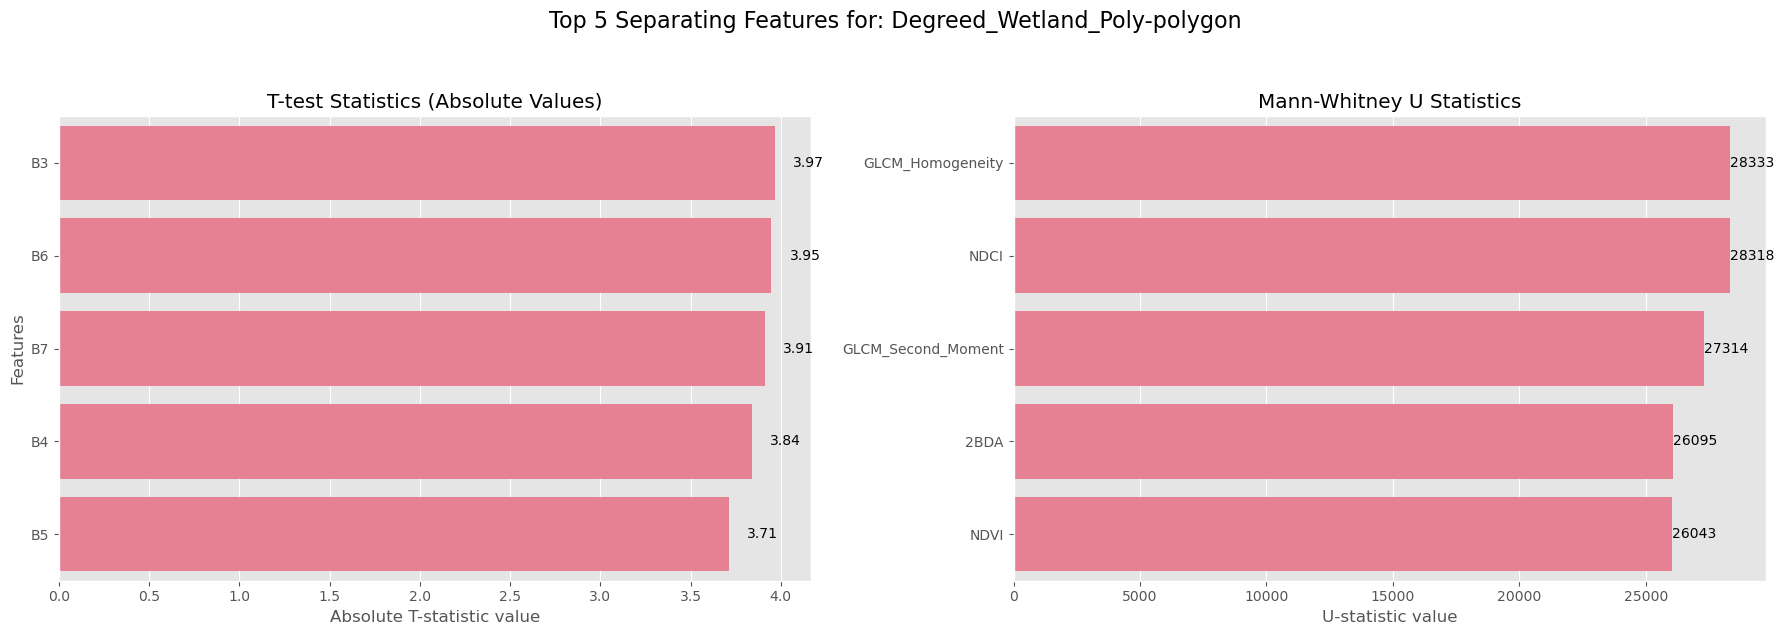


Heatmaps of feature importance across classes...


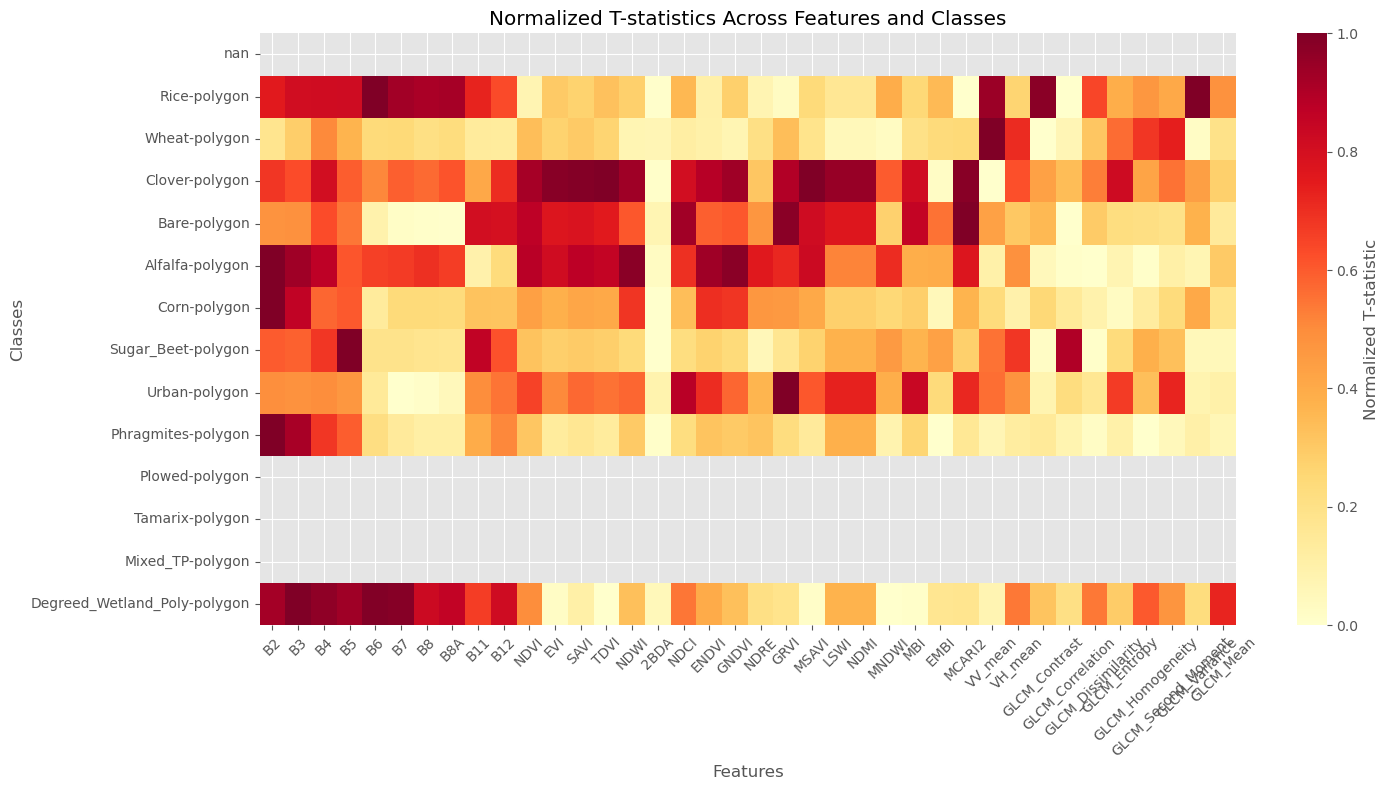

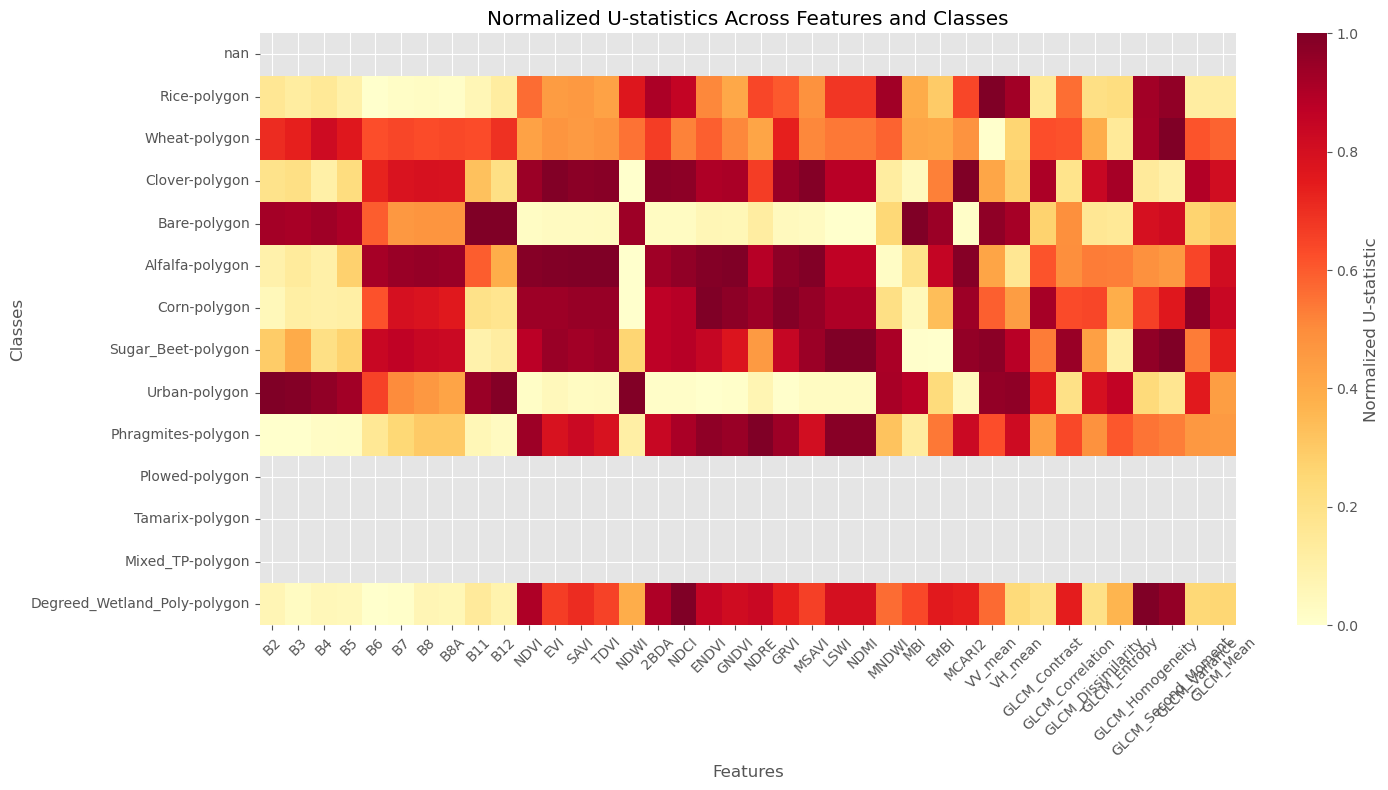


Trends of top features across all classes...


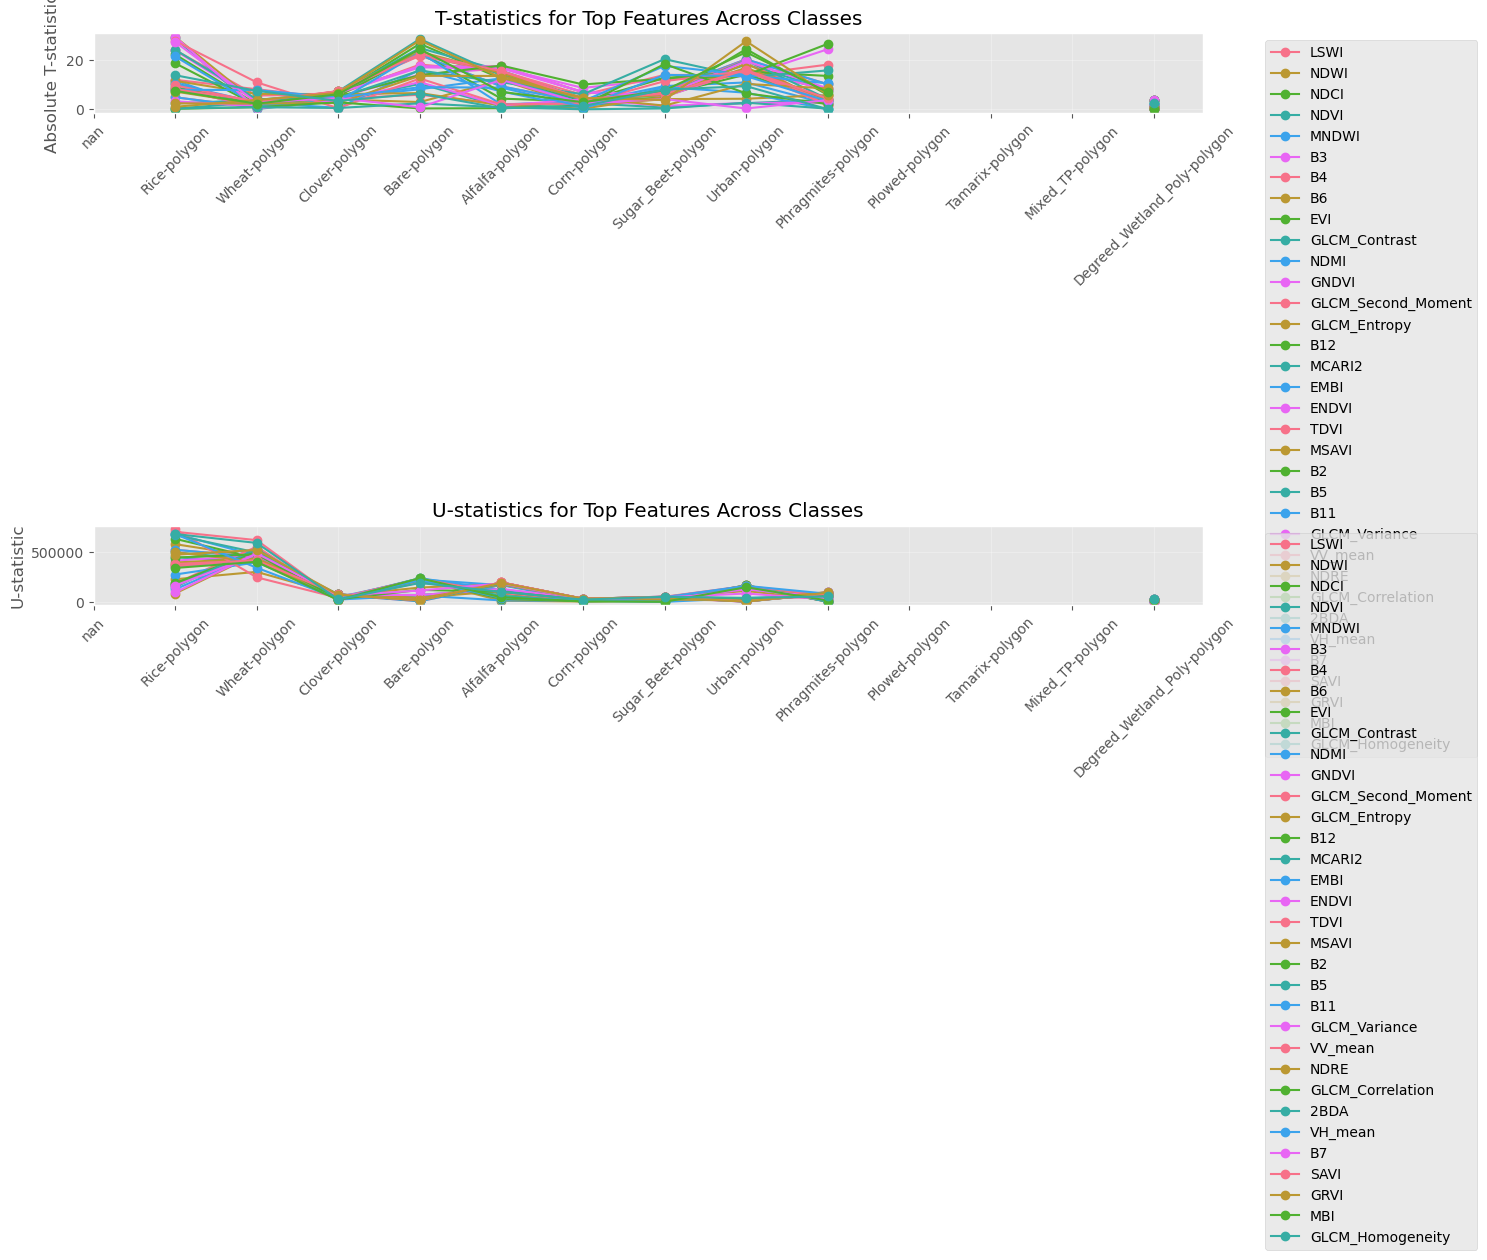

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_separability_stats(t_stats, u_stats, top_n=5):
    # Set up the style - using a more modern style that should be available
    try:
        plt.style.use('ggplot')  # Alternative styles: 'seaborn', 'ggplot', 'default'
    except:
        plt.style.use('default')
    sns.set_palette("husl")
    
    # For each class (layer), plot the top features
    for layer in t_stats.index:
        if pd.isna(layer):  # Skip NaN rows
            continue
            
        # Get top features for both tests
        top_t = t_stats.loc[layer].sort_values(ascending=False).head(top_n)
        top_u = u_stats.loc[layer].sort_values(ascending=False).head(top_n)
        
        # Skip if no valid data
        if len(top_t.dropna()) == 0 or len(top_u.dropna()) == 0:
            continue
            
        # Create figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(f'Top {top_n} Separating Features for: {layer}', fontsize=16, y=1.05)
        
        # Plot T-stats
        sns.barplot(x=top_t.values, y=top_t.index, ax=ax1)
        ax1.set_title('T-test Statistics (Absolute Values)')
        ax1.set_xlabel('Absolute T-statistic value')
        ax1.set_ylabel('Features')
        
        # Add value annotations for T-stats
        for i, v in enumerate(top_t.values):
            if not np.isnan(v):
                ax1.text(v + 0.1, i, f"{v:.2f}", color='black', ha="left", va="center")
        
        # Plot U-stats
        sns.barplot(x=top_u.values, y=top_u.index, ax=ax2)
        ax2.set_title('Mann-Whitney U Statistics')
        ax2.set_xlabel('U-statistic value')
        ax2.set_ylabel('')
        
        # Add value annotations for U-stats
        for i, v in enumerate(top_u.values):
            if not np.isnan(v):
                ax2.text(v + 0.1, i, f"{int(v)}", color='black', ha="left", va="center")
        
        plt.tight_layout()
        plt.show()

def plot_feature_importance_heatmaps(t_stats, u_stats):
    # Prepare data - normalize for better visualization
    t_norm = t_stats.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)
    u_norm = u_stats.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)
    
    # Plot heatmap for T-stats
    plt.figure(figsize=(15, 8))
    sns.heatmap(t_norm, cmap="YlOrRd", annot=False, 
                cbar_kws={'label': 'Normalized T-statistic'})
    plt.title('Normalized T-statistics Across Features and Classes')
    plt.xlabel('Features')
    plt.ylabel('Classes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot heatmap for U-stats
    plt.figure(figsize=(15, 8))
    sns.heatmap(u_norm, cmap="YlOrRd", annot=False, 
                cbar_kws={'label': 'Normalized U-statistic'})
    plt.title('Normalized U-statistics Across Features and Classes')
    plt.xlabel('Features')
    plt.ylabel('Classes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_top_features_across_classes(t_stats, u_stats, top_n=5):
    # Get top features across all classes for each test
    top_t_features = set()
    top_u_features = set()
    
    for layer in t_stats.index:
        if pd.isna(layer):
            continue
        top_t_features.update(t_stats.loc[layer].nlargest(top_n).index)
        top_u_features.update(u_stats.loc[layer].nlargest(top_n).index)
    
    # Combine to get unique top features
    all_top_features = list(top_t_features.union(top_u_features))
    
    # Create numeric x-axis values for plotting
    x_values = np.arange(len(t_stats.index))
    
    # Plot these features across classes
    plt.figure(figsize=(15, 10))
    
    # T-stats plot
    plt.subplot(2, 1, 1)
    for feature in all_top_features:
        plt.plot(x_values, t_stats[feature], 'o-', label=feature)
    plt.title('T-statistics for Top Features Across Classes')
    plt.ylabel('Absolute T-statistic')
    plt.xticks(x_values, t_stats.index, rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # U-stats plot
    plt.subplot(2, 1, 2)
    for feature in all_top_features:
        plt.plot(x_values, u_stats[feature], 'o-', label=feature)
    plt.title('U-statistics for Top Features Across Classes')
    plt.ylabel('U-statistic')
    plt.xticks(x_values, t_stats.index, rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Run the visualization functions
print("Visualizing top features for each class...")
visualize_separability_stats(t_stats, u_stats, top_n=5)

print("\nHeatmaps of feature importance across classes...")
plot_feature_importance_heatmaps(t_stats, u_stats)

print("\nTrends of top features across all classes...")
plot_top_features_across_classes(t_stats, u_stats, top_n=5)